# Packages

In [1]:
import GPKoopman as gpk
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, clear_output
import math
import itertools
from sklearn.cluster import KMeans

In [12]:
import torch
import scipy.io as sio

# Load the .pt file
data = torch.load('Data/DataAuto_Simple Pendulum.pt', weights_only=True)

# Convert torch tensors to numpy arrays
data_np = {key: value.numpy() if isinstance(value, torch.Tensor) else value
           for key, value in data.items()}

# Save the data to a .mat file
sio.savemat('Data/DataAuto_SimplePendulum.mat', data_np)


# Function Definitions

## Polynomial Basis eDMD

In [2]:
def generate_basis(x, degree):
    """
    Generate a polynomial basis for a 1D state vector x up to a given degree.
    
    Args:
        x (torch.Tensor): A 1D tensor of shape (d,).
        degree (int): Maximum degree of the polynomial basis.
    
    Returns:
        torch.Tensor: A 1D tensor containing the computed polynomial basis.
    """
    # Ensure x is 1D (if it's (d,1) or similar, squeeze it)
    if x.dim() > 1:
        x = x.squeeze()
    
    d = x.shape[0]  # Use the number of elements in the state vector, not the total elements.
    basis = [torch.tensor(1.0, dtype=x.dtype, device=x.device)]  # constant term
    
    for deg in range(1, degree + 1):
        for indices in itertools.combinations_with_replacement(range(d), deg):
            term = torch.prod(x[list(indices)])
            basis.append(term)
    
    return torch.stack(basis)

def generate_basis_batch(X, degree):
    """
    Generate a polynomial basis for each state vector in a batch.
    
    Args:
        X (torch.Tensor): A 2D tensor with shape (state_dim, num_states).
        degree (int): Maximum degree of the polynomial basis.
    
    Returns:
        torch.Tensor: A 2D tensor where each column is the polynomial basis of the corresponding state vector.
    """
    state_dim, num_states = X.shape
    # Compute the size of the basis by generating it once
    single_basis = generate_basis(X[:, 0], degree)
    basis_size = single_basis.numel()
    
    # Pre-allocate tensor for efficiency
    basis_tensor = torch.empty(basis_size, num_states, dtype=X.dtype, device=X.device)
    
    for i in range(num_states):
        basis_tensor[:, i] = generate_basis(X[:, i], degree)
    
    return basis_tensor

def eDMD_poly(SimData, nTrain, nTest, poly_deg=1):

    SimData = SimData.float()
    n, N = SimData.shape[1], SimData.shape[2] - 1

    X = torch.cat([SimData[j, :, 0:N] for j in range(nTrain)], dim=1)       # Concatenated Data matrix
    Xplus = torch.cat([SimData[j, :, 1:] for j in range(nTrain)], dim=1)    # Time-shifted Data matrix
    ICsetTrain = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain)], dim=1)
    ICsetTest = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain, nTrain + nTest)], dim=1)

    # Generate Polynomial Basis Function
    phi_batch = lambda X: generate_basis_batch(X, poly_deg)
    
    # Lift state with generated polynomial basis functions
    phi_x = phi_batch(X)
    phi_xplus = phi_batch(Xplus)

    # Compute eDMD matrices
    A_edmd = phi_xplus @ torch.linalg.pinv(phi_x)
    C_edmd = X @ torch.linalg.pinv(phi_x)
    p = C_edmd.shape[1]

    # Evaluation on training set
    ZedTrain = torch.empty((nTrain, p, N))    # n+p for state-augmentation
    #ZmeanTrain[:, :n, 0] = ICsetTrain.T    # only for state-augmentation

    XedTrain = torch.empty((nTrain, n, N))
    TrainRMSE_eDMD = torch.empty((nTrain,n))

    for j in range(nTrain): # Prediction for all training trajectories
        ZedTrain[j, :, 0] = phi_batch(ICsetTrain[:, j].view(n,1)).view(p,)        # n+i for state-augmentation
            
        ZedTrain[j, :, :], XedTrain[j, :, :] = gpk.sim_LTI(ZedTrain[j,:,0], A_edmd, C_edmd, num_steps=N, ts=None, x0cv=None)
        TrainRMSE_eDMD[j,:] = torch.sqrt(torch.mean((XedTrain[j,:,:] - SimData[j,:,:N])**2,1))


    # Evaluation on test set
    ZedTest = torch.empty((nTest, p, N))
    #ZmeanTest[:, :n, 0] = ICsetTest.T  # only for state-augmentation

    XedTest = torch.empty((nTest, n, N))
    TestRMSE_eDMD = torch.empty((nTest,n))

    for j in range(nTest): # Prediction for all testing trajectories
        ZedTest[j, :, 0] = phi_batch(ICsetTest[:, j].view(n,1)).view(p,)          # n+i for state-augmentation

        ZedTest[j, :, :], XedTest[j, :, :] = gpk.sim_LTI(ZedTest[j,:,0], A_edmd, C_edmd, num_steps=N, ts=None, x0cv=None)
        TestRMSE_eDMD[j,:] = torch.sqrt(torch.mean((XedTest[j,:,:] - SimData[nTest+j,:,:N])**2,1))

    XedTrain, XedTest = XedTrain.detach(), XedTest.detach()
    TestRMSE_eDMD, TrainRMSE_eDMD = TestRMSE_eDMD.detach(), TrainRMSE_eDMD.detach()

    return A_edmd, C_edmd, XedTrain, XedTest, TrainRMSE_eDMD, TestRMSE_eDMD

## RBF Basis eDMD

In [3]:
def generate_rbf_basis(x, centers, rbf_width):
    """
    Generate an RBF basis for a 1D state vector x using given centers.
    
    Args:
        x (torch.Tensor): A 1D tensor of shape (d,).
        centers (torch.Tensor): A 2D tensor of shape (d, m) where each column is an RBF center.
        rbf_width (float): The width (sigma) of the RBF.
    
    Returns:
        torch.Tensor: A 1D tensor containing the computed RBF basis.
    """
    # Ensure x is 1D (if provided as a (d,1) tensor, squeeze it)
    if x.dim() > 1:
        x = x.squeeze()
    
    # Compute differences between the state and each center; shape: (d, m)
    diffs = x.unsqueeze(1) - centers
    squared_norms = torch.sum(diffs**2, dim=0)  # shape: (m,)
    
    # Compute RBF values: exp(-||x - c||^2 / (2*sigma^2))
    rbf_values = torch.exp(-squared_norms / (2 * rbf_width**2))
    
    # Optionally include a constant term (bias)
    basis = torch.cat([torch.tensor([1.0], dtype=x.dtype, device=x.device), rbf_values])
    
    return basis

def generate_rbf_basis_batch(X, centers, rbf_width):
    """
    Generate an RBF basis for each state vector in a batch.
    
    Args:
        X (torch.Tensor): A 2D tensor with shape (state_dim, num_states).
        centers (torch.Tensor): A 2D tensor with shape (state_dim, m) for RBF centers.
        rbf_width (float): The width (sigma) of the RBF.
    
    Returns:
        torch.Tensor: A 2D tensor where each column is the RBF basis of the corresponding state vector.
    """
    state_dim, num_states = X.shape
    # Compute the basis for the first state vector to determine the basis size
    single_basis = generate_rbf_basis(X[:, 0], centers, rbf_width)
    basis_size = single_basis.numel()
    
    basis_tensor = torch.empty(basis_size, num_states, dtype=X.dtype, device=X.device)
    
    for i in range(num_states):
        basis_tensor[:, i] = generate_rbf_basis(X[:, i], centers, rbf_width)
        
    return basis_tensor

def get_kmeans(data, num_centers=1):
    """
    Compute K-Means clustering for the given data and return cluster centroids.

    Args:
        data (torch.Tensor or np.ndarray): Data of shape (dimension, samples).
        num_centers (int): Number of cluster centers (clusters) to compute.
    
    Returns:
        torch.Tensor: Cluster centroids of shape (dimension, num_centers).
    """
    # Convert data to NumPy array if necessary
    if isinstance(data, torch.Tensor):
        data_np = data.detach().cpu().numpy()
    else:
        data_np = np.array(data)
    
    # Transpose data to shape (samples, dimension) for scikit-learn
    data_np = data_np.T
    
    # Perform k-means clustering
    kmeans = KMeans(n_clusters=num_centers, random_state=0).fit(data_np)
    
    # Get centroids; shape will be (num_centers, dimension)
    centroids_np = kmeans.cluster_centers_
    
    # Convert centroids to a torch tensor and transpose to shape (dimension, num_centers)
    centroids = torch.from_numpy(centroids_np.T).float()
    
    return centroids

def rbf_observable(x, centers, width=None, rbf_type='gaussian', state_aug=False):
    """
    Computes RBF values for a set of points x given multiple centers, with a choice
    between a Gaussian RBF or a thin-plate spline RBF.

    Args:
        x (torch.Tensor): Input points of shape (d, samples), where d is the dimension 
                          and samples is the number of points.
        centers (torch.Tensor): RBF centers of shape (d, m), where m is the number of RBFs.
        width (float or torch.Tensor, optional): For Gaussian RBF, either a scalar or a 1D tensor 
                          of length m specifying the width for each RBF. This is ignored for 
                          the thin-plate spline RBF.
        rbf_type (str): Type of RBF to compute. Options are 'gaussian' or 'thin_plate'.
                        Default is 'gaussian'.
    
    Returns:
        torch.Tensor: RBF values of shape (m, samples), where each row corresponds to one RBF.
    """
    # Compute pairwise differences between each center and each sample.
    # x has shape (d, samples), centers has shape (d, m).
    # After unsqueezing:
    #   x -> (d, 1, samples)
    #   centers -> (d, m, 1)
    # Their difference broadcasts to shape (d, m, samples)
    diff = x.unsqueeze(1) - centers.unsqueeze(2)
    
    # Compute squared Euclidean distance for each center-sample pair.
    # Resulting shape: (m, samples)
    dist_sq = torch.sum(diff**2, dim=0)
    
    if rbf_type.lower() == 'gaussian':
        if width is None:
            raise ValueError("A width must be provided for the Gaussian RBF.")
        # Convert width to a tensor if necessary.
        if not torch.is_tensor(width):
            width = torch.tensor(width, dtype=dist_sq.dtype, device=dist_sq.device)
        
        # Reshape width for proper broadcasting: (m, 1) if it's a 1D tensor.
        if width.ndim == 0:
            widths = width
        elif width.ndim == 1:
            widths = width.view(-1, 1)
        else:
            raise ValueError("width must be a scalar or a 1D tensor of length m.")
        
        # Compute the Gaussian RBF: exp(-||x - c||^2 / (2 * width^2))
        phi = torch.exp(-dist_sq / (2 * widths**2))
    
    elif rbf_type.lower() == 'thin_plate':
        # For the thin-plate spline, ignore width.
        # Add a small constant to avoid log(0)
        r = torch.sqrt(dist_sq + 1e-4)
        # Compute the thin-plate spline RBF: ||x - c||^2 * log(||x - c||)
        phi = dist_sq * torch.log(r)
    
    else:
        raise ValueError("rbf_type must be either 'gaussian' or 'thin_plate'")
    
    if state_aug:
        return torch.vstack((x, phi))
    else:
        return phi

def eDMD_RBF(SimData, nTrain, nTest, centers, width=None, rbf_type='gaussian', state_aug=False):
    """
    Extended Dynamic Mode Decomposition (eDMD) using RBF observables defined via rbf_observable.
    
    Args:
        SimData (torch.Tensor): Simulation data of shape (num_trajectories, state_dim, num_time_steps).
        nTrain (int): Number of trajectories used for training.
        nTest (int): Number of trajectories used for testing.
        centers (torch.Tensor): RBF centers of shape (state_dim, m) where m is the number of RBFs.
        width (float or torch.Tensor, optional): For Gaussian RBF, either a scalar or a 1D tensor of length m.
            Ignored for thin-plate spline RBF.
        rbf_type (str): Type of RBF to use: 'gaussian' or 'thin_plate'.
    
    Returns:
        A_edmd (torch.Tensor): The estimated system matrix in the lifted space.
        C_edmd (torch.Tensor): The reconstruction matrix from the lifted space to the state space.
        XedTrain (torch.Tensor): Predicted training trajectories.
        XedTest (torch.Tensor): Predicted testing trajectories.
        TrainRMSE_eDMD (torch.Tensor): RMSE for each state in each training trajectory.
        TestRMSE_eDMD (torch.Tensor): RMSE for each state in each testing trajectory.
    """
    SimData = SimData.float()
    n, N = SimData.shape[1], SimData.shape[2] - 1

    # Concatenate data for training: X and its time-shifted version Xplus.
    X = torch.cat([SimData[j, :, 0:N] for j in range(nTrain)], dim=1)
    Xplus = torch.cat([SimData[j, :, 1:] for j in range(nTrain)], dim=1)
    # Initial conditions for training and testing.
    ICsetTrain = torch.cat([SimData[j, :, 0].view(n, 1) for j in range(nTrain)], dim=1)
    ICsetTest = torch.cat([SimData[j, :, 0].view(n, 1) for j in range(nTrain, nTrain + nTest)], dim=1)

    # Define the observable lifting function using rbf_observable.
    # It accepts inputs of shape (state_dim, num_points) and returns (m, num_points)
    #phi_batch = lambda X: rbf_observable(X, centers, width, rbf_type, state_aug)
    
    # Lift the data.
    phi_x = rbf_observable(X, centers, width, rbf_type, state_aug)       # shape: (m, total training samples)
    phi_xplus = rbf_observable(Xplus, centers, width, rbf_type, state_aug)

    # Compute the eDMD matrices using a pseudo-inverse.
    A_edmd = phi_xplus @ torch.linalg.pinv(phi_x)
    p = A_edmd.shape[0]  # p is the number of lifted observables (typically m).
    if state_aug:
        C_edmd = torch.zeros((n,p))
        for i in range(n):
            C_edmd[i,i] = 1.
    else:
        C_edmd = X @ torch.linalg.pinv(phi_x)

    # Evaluate on the training set.
    ZedTrain = torch.empty((nTrain, p, N))
    XedTrain = torch.empty((nTrain, n, N))
    TrainRMSE_eDMD = torch.empty((nTrain, n))

    for j in range(nTrain):
        # Lift the initial condition for the j-th training trajectory.
        ZedTrain[j, :, 0] = rbf_observable(ICsetTrain[:, j].view(n, 1), centers, width, rbf_type, state_aug).view(p,)
        # Simulate the lifted linear system.
        ZedTrain[j, :, :], XedTrain[j, :, :] = gpk.sim_LTI(ZedTrain[j, :, 0], A_edmd, C_edmd,
                                                           num_steps=N, ts=None, x0cv=None)
        # Compute RMSE on the j-th trajectory.
        TrainRMSE_eDMD[j, :] = torch.sqrt(torch.mean((XedTrain[j, :, :] - SimData[j, :, :N])**2, dim=1))

    # Evaluate on the test set.
    ZedTest = torch.empty((nTest, p, N))
    XedTest = torch.empty((nTest, n, N))
    TestRMSE_eDMD = torch.empty((nTest, n))

    for j in range(nTest):
        ZedTest[j, :, 0] = rbf_observable(ICsetTest[:, j].view(n, 1), centers, width, rbf_type, state_aug).view(p,)
        ZedTest[j, :, :], XedTest[j, :, :] = gpk.sim_LTI(ZedTest[j, :, 0], A_edmd, C_edmd,
                                                         num_steps=N, ts=None, x0cv=None)
        TestRMSE_eDMD[j, :] = torch.sqrt(torch.mean((XedTest[j, :, :] - SimData[nTrain+j, :, :N])**2, dim=1))

    # Detach results.
    XedTrain, XedTest = XedTrain.detach(), XedTest.detach()
    TrainRMSE_eDMD, TestRMSE_eDMD = TrainRMSE_eDMD.detach(), TestRMSE_eDMD.detach()

    return A_edmd, C_edmd, XedTrain, XedTest, TrainRMSE_eDMD, TestRMSE_eDMD


# Data Loading

In [4]:
# Allowed system names -
# "Unforced Duffing"
# "Unforced Duffing"_right - domain restricted to right equilibrium point only
# "van der Pol"
# "Simple Pendulum"
# "Lorenz"
# "Lotka Volterra"
# "Piecewise Linear"

system_name = 'Unforced Duffing'
data = torch.load(f"Data/DataAuto_{system_name}.pt", weights_only=True)

SimData = data["trajectories"] # Shape: (num_trajectories, state_dim, num_steps)
ts = data["sample_time"]
num_trajectories = data["num_trajectories"]
N = data["num_steps"]
nTrain = math.floor(num_trajectories * 0.8)
nTest = math.floor(num_trajectories * 0.2)

# Do eDMD

In [5]:
A_edmd, C_edmd, XhatTrain_edPoly, XhatTest_edPoly, TrainRMSE_edPoly, TestRMSE_edPoly = eDMD_poly(SimData, nTrain, nTest, poly_deg=3)

In [6]:
X = torch.cat([SimData[j, :, 0:N] for j in range(nTrain)], dim=1)
rbf_centers = get_kmeans(X, num_centers=10)
A_edmdrbf, C_edmdrbf, XhatTrain_edRBF, XhatTest_edRBF, TrainRMSE_edRBF, TestRMSE_edRBF = eDMD_RBF(SimData, nTrain, nTest, rbf_centers, width=0.2, rbf_type='thin_plate', state_aug=True)


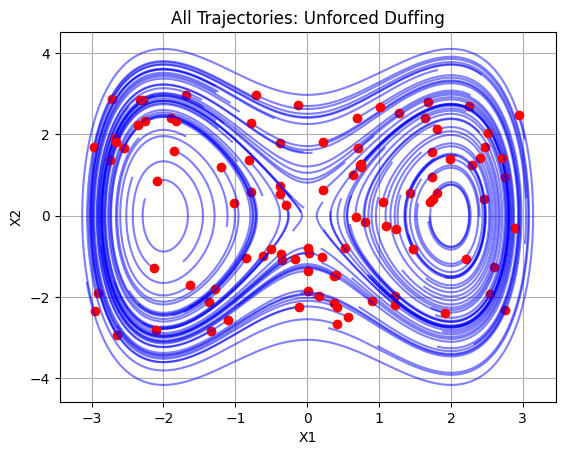

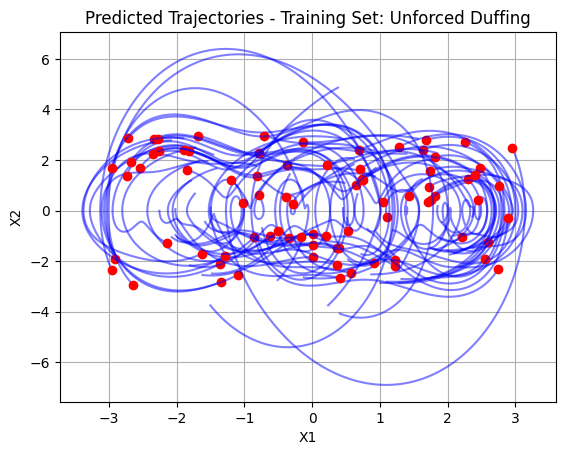

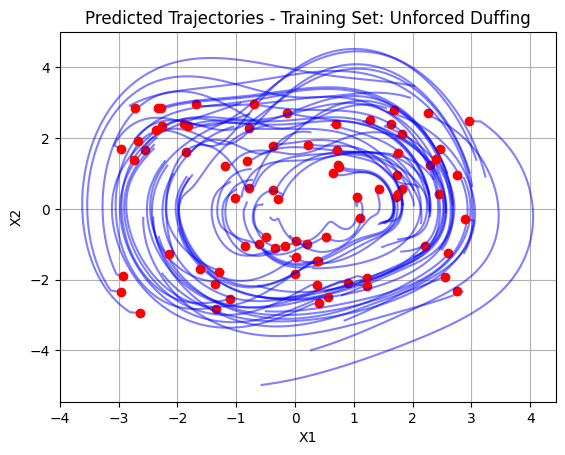

In [7]:
# Phase Diagram from all IC simulation
for j in range(SimData.shape[0]):
    plt.plot(SimData[j,0,:], SimData[j,1,:], alpha=0.5, color='blue')
    plt.plot(SimData[j,0,0], SimData[j,1,0], 'o', color='red')

plt.grid()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'All Trajectories: {system_name}')
plt.show()

# Training Set Predicted Trajectories
for j in range(XhatTrain_edPoly.shape[0]):
    plt.plot(XhatTrain_edPoly[j,0,:], XhatTrain_edPoly[j,1,:], alpha=0.5, color='blue')
    plt.plot(XhatTrain_edPoly[j,0,0], XhatTrain_edPoly[j,1,0], 'o', color='red')

plt.grid()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'Predicted Trajectories - Training Set: {system_name}')
plt.show()

for j in range(XhatTrain_edRBF.shape[0]):
    plt.plot(XhatTrain_edRBF[j,0,:], XhatTrain_edRBF[j,1,:], alpha=0.5, color='blue')
    plt.plot(XhatTrain_edRBF[j,0,0], XhatTrain_edRBF[j,1,0], 'o', color='red')

plt.grid()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'Predicted Trajectories - Training Set: {system_name}')
plt.show()